In [1]:
import os 
import numpy as np
import pandas as pd
from scipy.stats import zscore

import scanpy as sc 

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ddir = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized" 
!ls -alhtr $ddir/P28NRDR*

-rw-r--r--. 1 f7xiesnm zipursky 122M Apr 16  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240416.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 318M May  6  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240429.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 284M May  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240506.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 221M May  9  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240508.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 664M Aug  1  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 371M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1glut_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky  99M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/

In [3]:
ddir2 = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/astro_john/cellchat_from_riki"
!ls $ddir2

28nr_vs_28dr_celladhesion.R	     ECM-Receptor_p28nr_vs_28dr.csv
Cell-Cell_Contact_p28nr_vs_28dr.csv  Secreted_Signaling_p28nr_vs_28dr.csv


In [4]:
f = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/merfish_genes.txt"
genes_mer = np.loadtxt(f, dtype=str)
genes_mer.shape

(500,)

# CellChat data
- forget about `.y` for now

In [5]:
f1 = os.path.join(ddir2, 'Cell-Cell_Contact_p28nr_vs_28dr.csv')
f2 = os.path.join(ddir2, 'ECM-Receptor_p28nr_vs_28dr.csv')

df1 = pd.read_csv(f1, index_col=0)
df2 = pd.read_csv(f2, index_col=0)

df1

,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT
1,AST_AST_CADM1_CADM1,AST,AST,Cadm1,Cadm1,0.442968,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,0.00,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.011429,AST_AST,AST_AST,AST_AST_AST_AST
2,AST_AST_CDH2_CDH2,AST,AST,Cdh2,Cdh2,0.277887,0.0,CDH2_CDH2,Cdh2 - Cdh2,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,0.556131,AST_AST,NA_NA,AST_AST_NA_NA
3,AST_AST_CDH4_CDH4,AST,AST,Cdh4,Cdh4,0.015306,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.056838,AST_AST,AST_AST,AST_AST_AST_AST
4,AST_AST_JAM2_JAM2,AST,AST,Jam2,Jam2,0.012186,0.0,JAM2_JAM2,Jam2 - Jam2,JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,1.914150,AST_AST,NA_NA,AST_AST_NA_NA
5,AST_AST_LRRC4B_PTPRF,AST,AST,Lrrc4b,Ptprf,0.013946,0.0,LRRC4B_PTPRF,Lrrc4b - Ptprf,NGL,...,NaN,NaN,NaN,NaN,NaN,NaN,1.855541,AST_AST,NA_NA,AST_AST_NA_NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4746,Vlp_Vlp_NRXN3_NLGN1,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,0.00,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.305114,NA_NA,Vlp_Vlp,NA_NA_Vlp_Vlp
4747,Vlp_Vlp_NRXN3_NLGN2,Vlp,Vlp,Nrxn3,Nlgn2,0.090448,0.0,NRXN3_NLGN2,Nrxn3 - Nlgn2,NRXN,...,0.01,NRXN3_NLGN2,Nrxn3 - Nlgn2,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.025210,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp
4748,Vlp_Vlp_PTPRM_PTPRM,Vlp,Vlp,Ptprm,Ptprm,0.143255,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.00,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.508049,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp
4749,Vlp_Vlp_SEMA6A_PLXNA2,Vlp,Vlp,Sema6a,Plxna2,0.102426,0.0,SEMA6A_PLXNA2,Sema6a - Plxna2,SEMA6,...,0.00,SEMA6A_PLXNA2,Sema6a - Plxna2,SEMA6,Cell-Cell Contact,PMID: 27533782,0.039484,Vlp_Vlp,Vlp_Vlp,Vlp_Vlp_Vlp_Vlp


In [6]:
cond = np.logical_xor(
    df1['source.x'] == 'AST', 
    df1['target.x'] == 'AST', 
)

print(cond.sum())
df1sub = df1[cond]
df1sub

373


,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,pval.y,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT
13,AST_INH_CDH4_CDH4,AST,INH,Cdh4,Cdh4,0.014647,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NaN,NaN,NaN,NaN,NaN,NaN,1.834258,AST_INH,NA_NA,AST_INH_NA_NA
14,AST_INH_NCAM1_NCAM1,AST,INH,Ncam1,Ncam1,0.341554,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,...,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,Cell-Cell Contact,KEGG: mmu04514,0.002556,AST_INH,AST_INH,AST_INH_AST_INH
16,AST_L2/3_CADM1_CADM1,AST,L2/3,Cadm1,Cadm1,0.378108,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.002496,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3
17,AST_L2/3_CDH4_CDH4,AST,L2/3,Cdh4,Cdh4,0.033974,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.415612,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3
18,AST_L2/3_JAM2_ITGAV_ITGB1,AST,L2/3,Jam2,ITGAV_ITGB1,0.029990,0.0,JAM2_ITGAV_ITGB1,Jam2 - (Itgav+Itgb1),JAM,...,NaN,NaN,NaN,NaN,NaN,NaN,1.523031,AST_L2/3,NA_NA,AST_L2/3_NA_NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4470,Vlp_AST_NCAM1_NCAM1,Vlp,AST,Ncam1,Ncam1,0.317634,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,...,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,Cell-Cell Contact,KEGG: mmu04514,0.003489,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4471,Vlp_AST_NRXN2_NLGN1,Vlp,AST,Nrxn2,Nlgn1,0.310005,0.0,NRXN2_NLGN1,Nrxn2 - Nlgn1,NRXN,...,0.0,NRXN2_NLGN1,Nrxn2 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.012166,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4472,Vlp_AST_NRXN3_NLGN1,Vlp,AST,Nrxn3,Nlgn1,0.485558,0.0,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,...,0.0,NRXN3_NLGN1,Nrxn3 - Nlgn1,NRXN,Cell-Cell Contact,KEGG: mmu04514,0.011489,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST
4473,Vlp_AST_PTPRM_PTPRM,Vlp,AST,Ptprm,Ptprm,0.146098,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,...,0.0,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,0.228959,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST


In [7]:
mols = np.union1d(df1sub['ligand.x'].unique(), 
                  df1sub['receptor.x'].unique())
mols_mer = np.intersect1d(mols, genes_mer)
len(mols), len(mols_mer), mols_mer

(39,
 11,
 array(['Cdh4', 'Ncam2', 'Negr1', 'Nrxn1', 'Nrxn2', 'Ntng1', 'Plxna1',
        'Ptprf', 'Ptprm', 'Sema4a', 'Sema6d'], dtype=object))

In [8]:
cond2 = np.logical_and(
    df1sub['ligand.x'].isin(mols_mer),
    df1sub['receptor.x'].isin(mols_mer),
)
df1sub2 = df1sub[cond2]
len(df1sub2)

44

In [9]:
print(df1sub2['ligand.x'].unique())
print(df1sub2['receptor.x'].unique())
genes_cellchat = np.unique(np.hstack([df1sub2['ligand.x'], df1sub2['receptor.x']]))
genes_cellchat

['Cdh4' 'Ptprm' 'Negr1' 'Sema6d']
['Cdh4' 'Ptprm' 'Negr1' 'Plxna1']


array(['Cdh4', 'Negr1', 'Plxna1', 'Ptprm', 'Sema6d'], dtype=object)

In [10]:
df1sub2s = df1sub2[df1sub2['source.x']=='AST']
df1sub2t = df1sub2[df1sub2['target.x']=='AST']

In [11]:
summary_s = df1sub2s.groupby(['target.x', 'interaction_name.x']).size().unstack().fillna(0).astype(int).sort_index()
summary_t = df1sub2t.groupby(['source.x', 'interaction_name.x']).size().unstack().fillna(0).astype(int).sort_index()
summary_s = summary_s.drop(['L2/3/4', 'L4/L5IT', 'INH'])
summary_t = summary_t.drop(['L2/3/4', 'L4/L5IT', 'INH'])

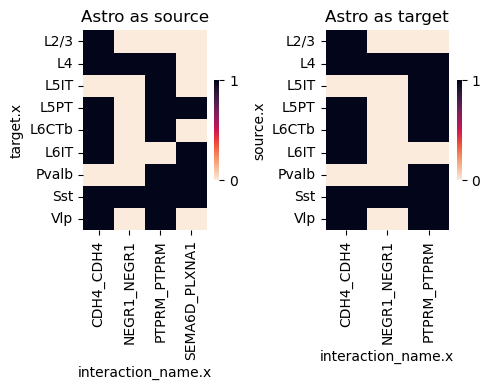

In [12]:
fig, axs = plt.subplots(1,2,figsize=(2.5*2,4))
ax = axs[0]
sns.heatmap(summary_s, 
            cbar_kws={'shrink':0.5, 'ticks': [0,1]}, cmap='rocket_r', ax=ax)
ax.set_title('Astro as source')

ax = axs[1]
sns.heatmap(summary_t, 
            cbar_kws={'shrink':0.5, 'ticks': [0,1]}, cmap='rocket_r', ax=ax)
ax.set_title('Astro as target')

fig.tight_layout()
plt.show()

# MERFISH data - check these 5 genes

In [13]:
def unify_labels(a, b):
    """
    """
    b = b.replace('NA', np.nan)
    
    cat_a = a.cat.categories
    cat_b = b.cat.categories
    
    if len(cat_a)==len(cat_b) and np.all(cat_a==cat_b):
        u = a.fillna(b)
    else:
        cats = np.union1d(cat_a, cat_b)
        a = a.cat.set_categories(cats).copy()
        b = b.cat.set_categories(cats).copy()
        u = a.fillna(b)
        
    return u

In [14]:
f = os.path.join(ddir, "P28NRDR_v1_rna_merfish_240729.h5ad")
adata = sc.read(f)

f = os.path.join(ddir, "P28NRDR_v1glut_rna_merfish_240729.h5ad")
adata_exc = sc.read(f, backed='r')
f = os.path.join(ddir, "P28NRDR_v1gaba_rna_merfish_240729.h5ad")
adata_inh = sc.read(f, backed='r')

# organize uClass and uSubclass
a = adata.obs['Class_broad']
b = adata.obs['gated_pred']
adata.obs['uClass'] = unify_labels(a, b)

a = adata_exc.obs['Subclass']
b = adata_exc.obs['gated_pred_subclass']
adata_exc.obs['uSubclass'] = unify_labels(a, b)

a = adata_inh.obs['Subclass']
b = adata_inh.obs['gated_pred_subclass']
adata_inh.obs['uSubclass'] = unify_labels(a, b)

uSubclass = pd.concat([adata_exc.obs['uSubclass'], adata_inh.obs['uSubclass']])
adata.obs = adata.obs.join(uSubclass)
adata.obs['uSubclass'] = adata.obs['uSubclass'].fillna(adata.obs['uClass'])
adata.obs

,batch,n_genes,percent_mito,n_counts,leiden,Doublet Score,cluster,Class_broad,sample,Age,...,leiden_r0.3,umap1,umap2,umap1_self,umap2_self,max_pred,frac_self_neighbors,gated_pred,uClass,uSubclass
AAACCCACAAATGATG-1-P28_1a-P28,P28,3450.0,0.000951,10513.0,3,0.023377,L6CT_B,Excitatory,P28_1a,P28,...,NaN,8.267126,17.154900,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCACACCCTAGG-1-P28_1a-P28,P28,4622.0,0.002900,15174.0,2,0.055276,L4_C,Excitatory,P28_1a,P28,...,NaN,11.621952,4.318666,NaN,NaN,NA,NaN,NA,Excitatory,L4
AAACCCAGTTCTCTCG-1-P28_1a-P28,P28,4895.0,0.002141,16814.0,6,0.040816,L2/3_B,Excitatory,P28_1a,P28,...,NaN,12.320524,-0.034990,NaN,NaN,NA,NaN,NA,Excitatory,L2/3
AAACCCATCACTTGTT-1-P28_1a-P28,P28,3751.0,0.000471,12745.0,3,0.012605,L6CT_B,Excitatory,P28_1a,P28,...,NaN,7.646397,16.957756,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCATCCTAGCTC-1-P28_1a-P28,P28,4327.0,0.001903,13661.0,1,0.028505,L4_C,Excitatory,P28_1a,P28,...,NaN,15.032149,6.807268,NaN,NaN,NA,NaN,NA,Excitatory,L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P28DRb_pos49001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,4.143420,5.953799,7.271769,5.800007,Oligodendrocytes,0.90,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes
P28DRb_pos49020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,3.795387,11.158264,4.908178,4.226176,OPCs,0.54,OPCs,OPCs,OPCs
P28DRb_pos49040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,2.996678,10.856749,4.674964,4.261509,OPCs,0.71,OPCs,OPCs,OPCs
P28DRb_pos49073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,5.964211,4.365138,7.940835,5.199085,Oligodendrocytes,0.56,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes


In [15]:
genes_cellchat_mer = np.intersect1d(adata.var.index.values, genes_cellchat)
genes_cellchat_mer

array(['Cdh4', 'Negr1', 'Ptprm', 'Sema6d'], dtype=object)

In [16]:
adata_rna = adata[adata.obs['modality']=='rna']
adata_mer = adata[adata.obs['modality']=='merfish']
adata_mer

View of AnnData object with n_obs × n_vars = 43961 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'uClass', 'uSubclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'connectivities', 'distances'

In [17]:
sel_adata = adata_rna
sel_col = 'uSubclass'
sel_layer = 'lognorm'
sel_genes = genes_cellchat_mer
sel_data = np.array(sel_adata[:,sel_genes].layers[sel_layer].todense())

dfval = sel_adata.obs[[sel_col]].copy()
dfval[sel_genes] = sel_data
dfval_mean = dfval.groupby(sel_col).mean()
dfval_mean_zscore = zscore(dfval_mean, axis=0)
print(dfval_mean.mean())

Cdh4      0.147746
Negr1     1.031003
Ptprm     0.481507
Sema6d    0.516741
dtype: float64


In [18]:
sel_adata = adata_mer 
sel_col = 'uSubclass'
sel_layer = 'ljnorm'
sel_genes = genes_cellchat_mer
sel_data = np.array(sel_adata[:,sel_genes].layers[sel_layer])

dfval2 = sel_adata.obs[[sel_col]].copy()
dfval2[sel_genes] = sel_data
dfval2_mean = dfval2.groupby(sel_col).mean()
dfval2_mean_zscore = zscore(dfval2_mean, axis=0)
print(dfval2_mean.mean())

Cdh4      0.278332
Negr1     0.289261
Ptprm     0.888070
Sema6d    0.278680
dtype: float64


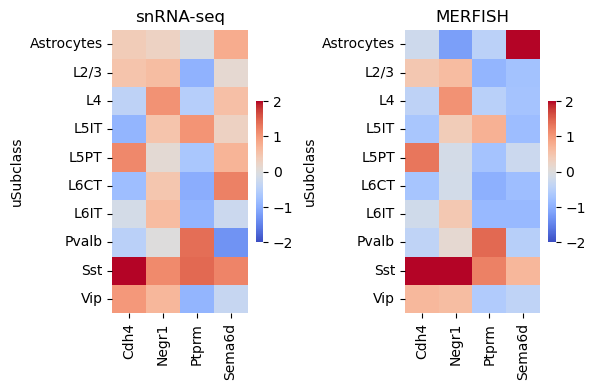

In [19]:
selrows = [
    "Astrocytes", 
    
    "L2/3", "L4", 
    "L5IT", "L5PT", 
    "L6CT", "L6IT",
    "Pvalb", "Sst", "Vip",
    
    # "Endothelial",
    # "OPCs",
    # "Oligodendrocytes",
    # "Microglia",
    # "VLMCs",
]

fig, axs = plt.subplots(1,2,figsize=(3*2,1*4))
ax = axs[0]
ax.set_title('snRNA-seq')
sns.heatmap( dfval_mean_zscore.loc[selrows],
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax = axs[1]
ax.set_title('MERFISH')
sns.heatmap(dfval2_mean_zscore.loc[selrows], 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()